In [12]:
import pandas as pd

from google.colab import files
uploaded = files.upload()  # click and upload your CSV file

Saving bank[1].csv to bank[1].csv


In [16]:
from google.colab import files
uploaded = files.upload()

Saving bank[1].csv to bank[1] (1).csv


In [18]:
import pandas as pd
df = pd.read_csv("bank[1].csv", sep=";")
print(df.head())

  age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0  59,admin.,married,secondary,no,2343,yes,no,unk...                                                                        
1  56,admin.,married,secondary,no,45,no,no,unknow...                                                                        
2  41,technician,married,secondary,no,1270,yes,no...                                                                        
3  55,services,married,secondary,no,2476,yes,no,u...                                                                        
4  54,admin.,married,tertiary,no,184,no,no,unknow...                                                                        


In [19]:
import pandas as pd
df = pd.read_csv("bank[1].csv", sep=",")
print(df.head())
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())

   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  

Shape: (11162, 17)

Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing

In [20]:
print(df["balance"].mean())
print(df["balance"].max())
print(df["balance"].min())
print(df["age"].mean())

1528.5385235620856
81204
-6847
41.231947679627304


In [21]:
print(df.groupby("job")["balance"].mean())

job
admin.           1195.866567
blue-collar      1203.926440
entrepreneur     1621.942073
housemaid        1366.160584
management       1793.663679
retired          2417.250643
self-employed    1865.372840
services         1081.171181
student          1500.783333
technician       1556.294569
unemployed       1314.719888
unknown          1945.457143
Name: balance, dtype: float64


In [22]:
rich = df[df["balance"] > 5000]
print("High balance customers:", len(rich))

High balance customers: 771


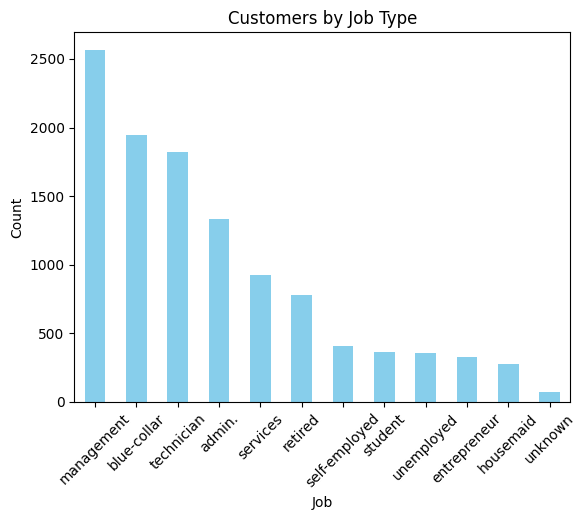

In [23]:
import matplotlib.pyplot as plt

df["job"].value_counts().plot(kind="bar", color="skyblue")
plt.title("Customers by Job Type")
plt.xlabel("Job")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [24]:
# Find customers in debt
debt_customers = df[df["balance"] < 0]
print("Customers in debt:", len(debt_customers))
print(debt_customers[["age", "job", "marital", "balance"]].head(10))

Customers in debt: 688
    age           job   marital  balance
17   49      services   married       -8
23   43   blue-collar   married     -192
30   32   blue-collar   married       -1
42   45  entrepreneur  divorced     -395
59   57    technician   married       -1
63   52   blue-collar  divorced     -191
67   40      services   married       -9
68   41        admin.   married     -306
72   41       retired  divorced     -233
82   33   blue-collar    single     -416


In [25]:
# Which job has most debt customers?
print(debt_customers["job"].value_counts())

# Average debt by job
print(debt_customers.groupby("job")["balance"].mean())

job
blue-collar      211
technician       109
management       109
admin.            89
services          79
entrepreneur      27
retired           23
self-employed     18
unemployed        14
housemaid          9
Name: count, dtype: int64
job
admin.          -272.943820
blue-collar     -255.663507
entrepreneur    -422.777778
housemaid       -474.111111
management      -448.311927
retired         -296.217391
self-employed   -440.888889
services        -283.075949
technician      -363.697248
unemployed      -231.357143
Name: balance, dtype: float64


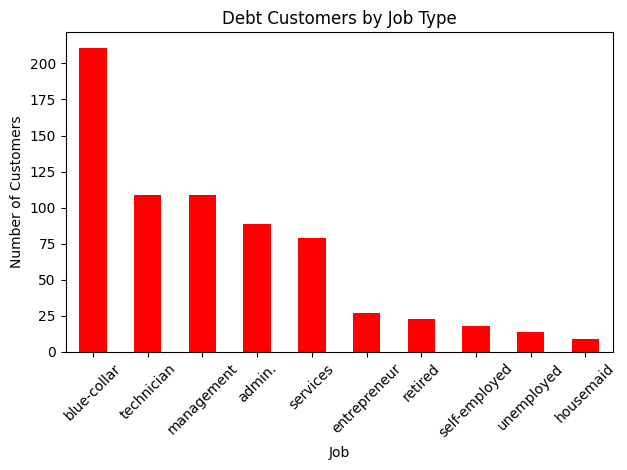

In [26]:
import matplotlib.pyplot as plt

debt_customers["job"].value_counts().plot(kind="bar", color="red")
plt.title("Debt Customers by Job Type")
plt.xlabel("Job")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
# Save analysis to CSV
debt_customers.to_csv("debt_analysis.csv", index=False)
print("Saved!")

Saved!


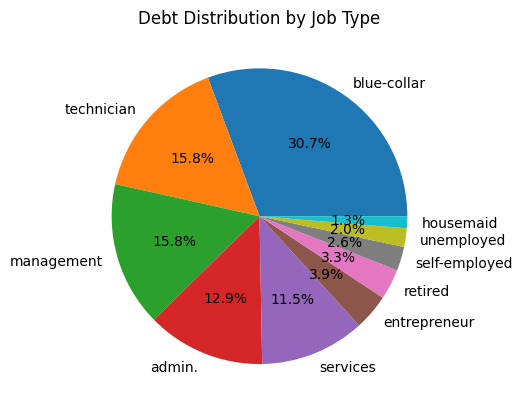

In [28]:
# Pie chart of debt by job
debt_by_job = debt_customers["job"].value_counts()

plt.pie(debt_by_job, labels=debt_by_job.index, autopct="%1.1f%%")
plt.title("Debt Distribution by Job Type")
plt.show()